In [1]:
# # This Python 3 environment comes with many helpful analytics libraries installed
# # It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# # For example, here's several helpful packages to load

# import numpy as np # linear algebra
# import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# # Input data files are available in the read-only "../input/" directory
# # For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# # You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# # You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Load & Preprocess the Data

In [2]:
%%capture
!pip install transformers datasets accelerate -q
!pip install evaluate

In [3]:
import numpy as np
import pandas as pd
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, EarlyStoppingCallback
import evaluate

In [4]:
en_train  = pd.read_csv('/kaggle/input/hope-speech-detection-across-multiple-languages/Training_Data_PolyHope-M_2025/Training Data/es_train.csv')
en_dev = pd.read_csv('/kaggle/input/hope-speech-detection-across-multiple-languages/Training_Data_PolyHope-M_2025/Training Data/es_dev.csv')
en_test = pd.read_csv('/kaggle/input/hope-speech-detection-across-multiple-languages/TestWithNoLabel/TestWithNoLabel/es_test_without_labels.csv')
en_train

,text,binary,multiclass
0,🎬Outer Banks🎬 (temporada 3) la verdad que teni...,Hope,Generalized Hope
1,-Después del poco éxito en el grupo de la Jet ...,Hope,Generalized Hope
2,Bárbara López yo te rezo y te hago un monument...,Hope,Generalized Hope
3,RT #USER# #USER# #USER# Ojalá nos ayuden a des...,Hope,Realistic Hope
4,#USER# No tengo las palabras justas. Pero rezo...,Hope,Realistic Hope
...,...,...,...
10545,Estamos deseando disfrutar de la conversación ...,Hope,Generalized Hope
10546,#USER# #USER# #USER# #USER# Coincido. Ya estoy...,Hope,Generalized Hope
10547,Tengo una pregunta un tanto boba pero que no e...,Hope,Generalized Hope
10548,¡#Josedeodo 🎮🔥 HA EMITIDO en #Twitch! 🇦🇷 Nuest...,Not Hope,Not Hope


In [5]:
len(en_dev)

3837

In [6]:
label_mapping = {'Hope': 1, 'Not Hope': 0}

en_train['binary'] = en_train['binary'].map(label_mapping)
en_dev['binary'] = en_dev['binary'].map(label_mapping)

en_train.drop(columns=['multiclass'], inplace=True)
en_dev.drop(columns=['multiclass'], inplace=True)

en_train.dropna(inplace=True)
en_dev.dropna(inplace=True)

In [7]:
en_dev

,text,binary
0,#USER# #USER# Ole ahí chaval 👏👏 este año yo cr...,1
1,"#USER# Si todo bien, yo deseo lo mismo. Dios u...",1
2,#USER# Ojalá llueva con intensidad para paliar...,1
3,#USER# Dígale ya es vital que los profesores c...,0
4,#AGRADECIMIENTOS | Finalizados los cultos en ...,1
...,...,...
3832,Podemos tener la esperanza de que algún Juez o...,1
3833,Los recuerdos de los dias amarillos en el pueb...,1
3834,RT #USER# Mi mamá: Van a venir tus tías a reza...,0
3835,#USER# #USER# Lo unico que me da esperanza es ...,1


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/616 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

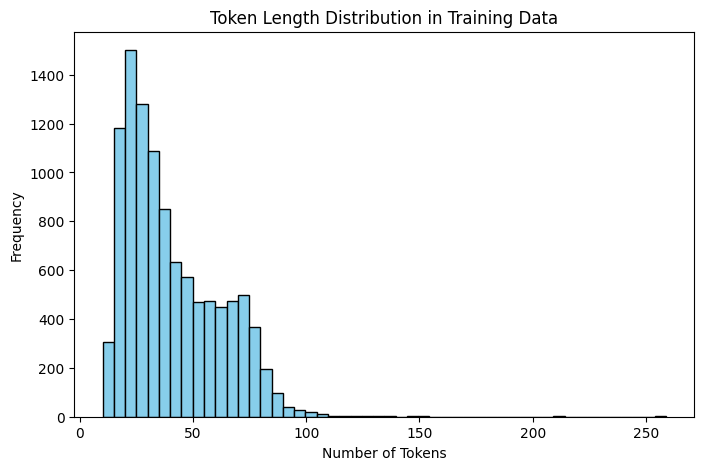

In [8]:
from transformers import AutoTokenizer
import matplotlib.pyplot as plt

tokenizer = AutoTokenizer.from_pretrained("xlm-roberta-large")

# Tokenize training data and get lengths
train_text_lengths = [len(tokenizer.tokenize(text)) for text in en_train['text']]

# Plot the distribution
plt.figure(figsize=(8,5))
plt.hist(train_text_lengths, bins=50, color='skyblue', edgecolor='black')
plt.xlabel("Number of Tokens")
plt.ylabel("Frequency")
plt.title("Token Length Distribution in Training Data")
plt.show()


In [9]:
# Use the percentile method:
Max_length = min(512,int(np.percentile(train_text_lengths, 96)))  # Covers 96% of texts
Max_length

79

# Tokenization with XLM-RoBERTa

In [10]:
# Tokenization function
def tokenize_data(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=Max_length)

# Apply tokenization
train_texts = en_train["text"].tolist()
train_labels = en_train["binary"].tolist()

dev_texts = en_dev["text"].tolist()
dev_labels = en_dev["binary"].tolist()

train_encodings = tokenizer(train_texts, padding=True, truncation=True, max_length=Max_length)
dev_encodings = tokenizer(dev_texts, padding=True, truncation=True, max_length=Max_length)

# Convert Data to PyTorch Dataset

In [11]:
import torch

class HopeDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

train_dataset = HopeDataset(train_encodings, train_labels)
dev_dataset = HopeDataset(dev_encodings, dev_labels)

# Load Pre-Trained Model

In [12]:
# Load Model with Updated Dropout
model = AutoModelForSequenceClassification.from_pretrained("xlm-roberta-large", num_labels=4)
model.config.hidden_dropout_prob = 0.3  # Increased to improve generalization
model.config.attention_probs_dropout_prob = 0.3  # Helps prevent overfitting
model.gradient_checkpointing_enable()  # Saves memory and improves stability

model.safetensors:   0%|          | 0.00/2.24G [00:00<?, ?B/s]

Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-large and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


#  Define Training Arguments

In [13]:
# Updated Training Arguments for Best Performance
training_args = TrainingArguments(
    output_dir="./results",
    per_device_train_batch_size=8,  # Increased batch size for better gradient updates
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=2,  # Reduced slightly for better optimization
    evaluation_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=1,  # Keep only 1 checkpoint
    load_best_model_at_end=True,  # Ensure best checkpoint is restored
    metric_for_best_model="f1",  # Focus on F1-score optimization
    num_train_epochs=60,
    weight_decay=0.05,  # Reduced to avoid over-regularization
    learning_rate=2e-5,  # Slightly increased for better convergence
    warmup_ratio=0.2,  # Increased to stabilize training
    lr_scheduler_type="cosine",
    logging_dir="./logs",
    logging_steps=50,
    report_to="none",
    fp16=True,  # Mixed-precision training
    gradient_checkpointing=True,  # Saves memory
    optim="adamw_torch",  # More efficient AdamW optimizer
    adam_beta1=0.9,  # Default
    adam_beta2=0.98,  # Helps with regularization
    max_grad_norm=1.0,  # Gradient clipping to avoid explosion
)

/usr/local/lib/python3.10/dist-packages/transformers/training_args.py:1575: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


# Define Metrics for Evaluation

In [14]:
# Metrics
accuracy = evaluate.load("accuracy")
f1 = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = accuracy.compute(predictions=predictions, references=labels)
    f1_score = f1.compute(predictions=predictions, references=labels, average="macro")
    return {"accuracy": acc["accuracy"], "f1": f1_score["f1"]}

# Initialize Trainer and Fine-Tune the Model

In [15]:
# Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=dev_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]  # Slightly relaxed early stopping
)

# Clear previous checkpoints
!rm -rf ./results/checkpoint*

# Start Training
trainer.train()


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.701200,0.672537,0.624186,0.613117
2,0.415100,0.422461,0.819651,0.819124
3,0.399100,0.408283,0.827991,0.826954
4,0.325400,0.464566,0.838155,0.837621
5,0.353900,0.414097,0.835027,0.834266
6,0.257600,0.575912,0.842846,0.842726
7,0.257900,0.485328,0.836852,0.836527
8,0.223000,0.696976,0.824603,0.823311
9,0.238600,0.629479,0.837373,0.837195


TrainOutput(global_step=5940, training_loss=0.3793000914031006, metrics={'train_runtime': 4678.196, 'train_samples_per_second': 135.309, 'train_steps_per_second': 8.452, 'total_flos': 1.36533417802812e+16, 'train_loss': 0.3793000914031006, 'epoch': 9.0})

# Evaluate the Model

In [16]:
trainer.evaluate()


{'eval_loss': 0.5759124159812927,
 'eval_accuracy': 0.8428459734167318,
 'eval_f1': 0.8427259446849582,
 'eval_runtime': 37.07,
 'eval_samples_per_second': 103.507,
 'eval_steps_per_second': 12.948,
 'epoch': 9.0}

# Save the Model

In [17]:
# Save the fine-tuned model
output_dir = "/kaggle/working/xlm-roberta-hope"
model.save_pretrained(output_dir)
tokenizer.save_pretrained(output_dir)

('/kaggle/working/xlm-roberta-hope/tokenizer_config.json',
 '/kaggle/working/xlm-roberta-hope/special_tokens_map.json',
 '/kaggle/working/xlm-roberta-hope/sentencepiece.bpe.model',
 '/kaggle/working/xlm-roberta-hope/added_tokens.json',
 '/kaggle/working/xlm-roberta-hope/tokenizer.json')

In [18]:
import torch
import pandas as pd
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.utils.data import DataLoader, TensorDataset

# Load Model & Tokenizer
model_path = "/kaggle/working/xlm-roberta-hope"  # Update path if needed
tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path)
model.eval()  # Set to evaluation mode

# Move Model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Ensure 'en_test' DataFrame exists
if "en_test" not in globals():
    raise ValueError("❌ 'en_test' DataFrame is not defined.")

test_texts = en_test["text"].tolist()  # Ensure 'text' column exists in test CSV


encoded_inputs = tokenizer(
    test_texts, truncation=True, padding=True, max_length=Max_length, return_tensors="pt"
)

# Keep tensors on CPU initially for DataLoader compatibility
input_ids = encoded_inputs["input_ids"]  # Keep as LongTensor
attention_mask = encoded_inputs["attention_mask"]  # Will move to GPU later

# Define batch size to avoid OOM
batch_size = 16  # Adjust based on available GPU memory
dataset = TensorDataset(input_ids, attention_mask)
dataloader = DataLoader(dataset, batch_size=batch_size)  # ❌ Removed pin_memory=True

# Prediction Loop with Memory Optimization
predictions = []
with torch.no_grad():
    for batch in dataloader:
        input_ids, attention_mask = batch

        # Move tensors to GPU inside the loop
        input_ids = input_ids.to(device, dtype=torch.long)
        attention_mask = attention_mask.to(device, dtype=torch.float16)  # Optional for optimization

        # Mixed Precision with Correct autocast
        with torch.amp.autocast("cuda"):  
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits
            batch_predictions = torch.argmax(logits, dim=1).cpu().numpy()
            predictions.extend(batch_predictions)
        
        # Clear cache to prevent memory overflow
        torch.cuda.empty_cache()

# # Convert Predictions to Original Labels
# label_map = {0: "Not Hope", 1: "Generalized Hope", 2: "Realistic Hope", 3: "Unrealistic Hope"}

label_map = {0: "Not Hope", 1: "Hope"}
predicted_labels = [label_map[pred] for pred in predictions]

# Save Predictions to CSV
submission_df = pd.DataFrame({"Text": test_texts, "Tag": predicted_labels})
submission_df.to_csv("predictions.csv", index=False)

print("✅ Predictions successfully saved to 'predictions.csv' using GPU.")


✅ Predictions successfully saved to 'predictions.csv' using GPU.
